In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

# 1. LOAD THE FILTERED DATA
# This is the file we specifically saved for regression in Step 3
df_semi = pd.read_csv('Semiconductors_Only_Data.csv')

# 2. FEATURE SELECTION
# We use the physics features to predict the 'band_gap' value
X = df_semi.drop(['formula', 'band_gap', 'is_semiconductor', 'B_site'], axis=1)
y = df_semi['band_gap']

# 3. DATA SCALING
# We must scale the data so that large numbers (like volume) 
# don't overwhelm small numbers (like electronegativity).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. TRAIN-TEST SPLIT
# We use 15% for testing (Exam) and 85% for training (Study)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.15, random_state=42)

print(f"✅ Step 4 Initialized.")
print(f"Ready to train on {len(X_train)} samples.")

✅ Step 4 Initialized.
Ready to train on 1556 samples.


In [3]:
# 1. DEFINE THE PARAMETERS TO TEST
# We are 'tuning the knobs' of the AI to find the best physics engine.
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

# 2. RUN THE GRID SEARCH
gbr = GradientBoostingRegressor(random_state=42)

print("Searching for the Optimized Physics Engine... (This may take a minute)")
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=5, n_jobs=-1, scoring='r2')
grid_search.fit(X_train, y_train)

# 3. GET THE BEST MODEL
best_regressor = grid_search.best_estimator_

print(f"\n✅ Optimization Complete!")
print(f"Best Parameters: {grid_search.best_params_}")

# 4. FINAL ACCURACY CHECK
y_pred = best_regressor.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n--- Model Accuracy ---")
print(f"R-squared: {r2:.4f}")
print(f"Error (MAE): {mae:.4f} eV")

Searching for the Optimized Physics Engine... (This may take a minute)

✅ Optimization Complete!
Best Parameters: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

--- Model Accuracy ---
R-squared: 0.7278
Error (MAE): 0.5273 eV


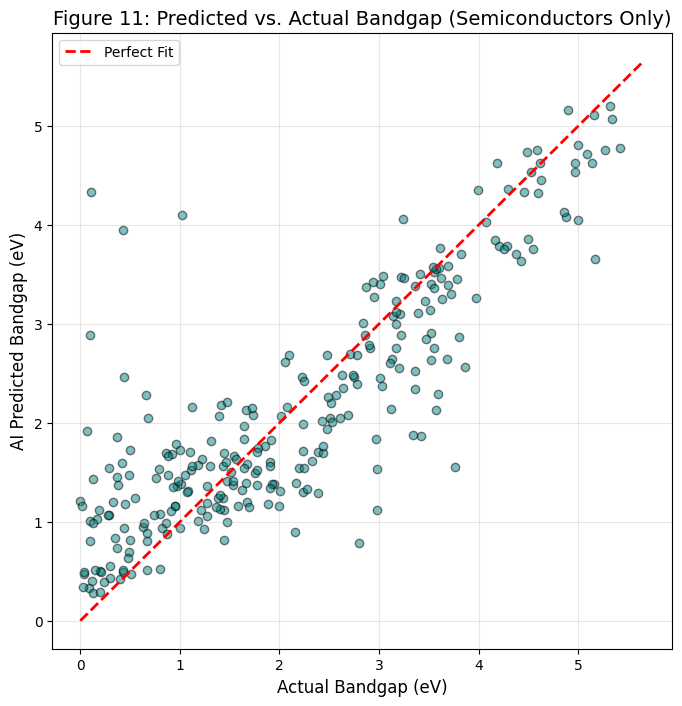

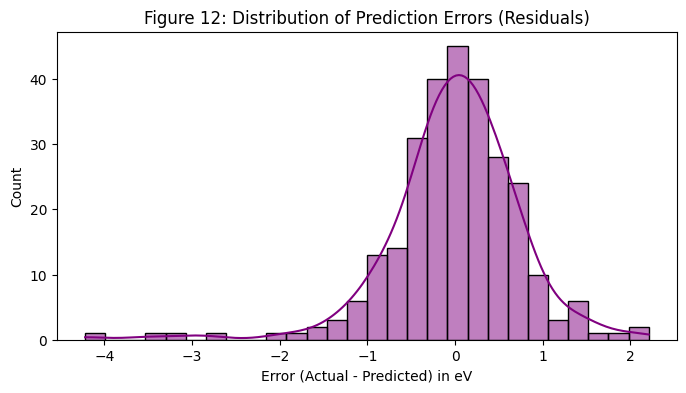

In [4]:
# 1. GENERATE PREDICTIONS
y_pred = best_regressor.predict(X_test)

# 2. CREATE THE PARITY PLOT
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal', edgecolors='k')

# Draw the 'Perfect Prediction' line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Fit')

plt.title('Figure 11: Predicted vs. Actual Bandgap (Semiconductors Only)', fontsize=14)
plt.xlabel('Actual Bandgap (eV)', fontsize=12)
plt.ylabel('AI Predicted Bandgap (eV)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. CALCULATE 'RESIDUALS' (To see if we have a bias)
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Figure 12: Distribution of Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted) in eV')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_19088\1110082578.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df.head(10), palette='viridis')


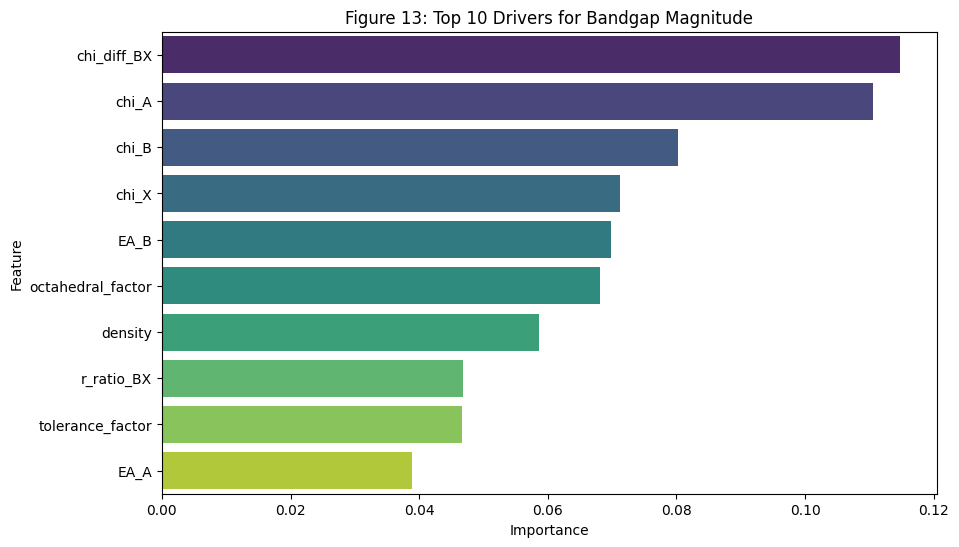

--- Solar Candidate Discovery ---
Found 69 candidates in the ideal solar range.
      Formula  Actual  Predicted
220    CaSnS3  0.9076   1.104574
1324  RbCuCl3  0.1859   1.117445
816    LaMnO3  1.4409   1.122922
838     LaWN3  1.2096   1.123065
1666    TlVO3  2.9763   1.123436
237    CaTcN3  1.4065   1.129918
818    LaMnO3  1.6926   1.151943
44     AlFeO3  1.3608   1.153526
1713    VGeO3  0.0143   1.156643
1232   NbTlO3  0.9550   1.159626

✅ Step 4 Specialist Model Saved.


In [5]:
import joblib

# 1. FEATURE IMPORTANCE FOR REGRESSION
importances = best_regressor.feature_importances_
feat_names = X.columns
feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10), palette='viridis')
plt.title('Figure 13: Top 10 Drivers for Bandgap Magnitude')
plt.show()

# 2. THE SOLAR DISCOVERY (Virtual Screening)
# We find materials where the AI predicts a gap between 1.1 and 1.6 eV
df_test_results = pd.DataFrame({'Formula': df_semi.iloc[y_test.index]['formula'], 
                                'Actual': y_test.values, 
                                'Predicted': y_pred})

solar_candidates = df_test_results[(df_test_results['Predicted'] >= 1.1) & 
                                   (df_test_results['Predicted'] <= 1.6)].sort_values(by='Predicted')

print(f"--- Solar Candidate Discovery ---")
print(f"Found {len(solar_candidates)} candidates in the ideal solar range.")
print(solar_candidates.head(10))

# 3. SAVE THE SPECIALIST MODEL
joblib.dump(best_regressor, 'Perovskite_Regressor_Model.joblib')
print("\n✅ Step 4 Specialist Model Saved.")